# Data Understanding, Description, and Summary

**If you are using Google Colab**

If you use Google Colab, uncomment and run the next cell to mount your Google Drive. After mounting, Colab can read files from your Drive and save files back to it.<br>

Then change the current directory to the folder where you saved this notebook and the data folder. For example, my Colab files and data are saved in the following location:

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

#%cd /content/drive/MyDrive/Colab\ Notebooks

**Set up the standard imports for the rest of the notebook**

In [2]:
# import required libraries and modules, and define default setting for the notebook

import numpy as np # https://numpy.org/
np.random.seed(12345)
np.set_printoptions(precision=4, suppress=True)

import pandas as pd # https://pandas.pydata.org/
from pandas import Series, DataFrame
PREVIOUS_MAX_ROWS = pd.options.display.max_rows
pd.options.display.max_rows = 30
pd.options.display.max_columns = 20
pd.options.display.max_colwidth = 80

import matplotlib.pyplot as plt 
plt.rc("figure", figsize=(10, 6))

# to display multiple outputs in one cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Get to Know the Dataset

In this section, we will develop an initial understanding of `NY_Bicycle.csv`, a dataset originally from [NYC Open Data](
https://data.cityofnewyork.us/Transportation/Bicycle-Counts-for-East-River-Bridges-Historical-/gua4-p9wg/about_data).

The dataset records daily bicycle counts for East River bridge crossings into or out of Manhattan. It includes seven months of observations and excludes Bronx thruways and the non-bikeable Hudson River tunnels. Transportation planners can use this type of dataset to understand bicycle activity patterns and support planning decisions.

### DataFrame

In this notebook, we will use `pandas`, a Python package for working with structured data. The main pandas objects we will use are `Series`, `DataFrame`, and `Index`.

Suggested exercises:

1. Load the CSV file. Read `NY_Bicycle.csv` as a DataFrame. [Hint: use `pd.read_csv()`]
2. Take a first look at the data. Display the first few rows. [Hint: use `.head()`]
3. Do you see any column that is not meaningful? [Hint: check column 0.] If the column is not useful, delete it. [Hint: use `del`]
4. What columns, variables, or attributes are in the dataset? What are their data types? [Hint: use `.info()` or `.columns`]
5. Check the name of a specific column. What is the name of column 4? [Hint: column names are stored in the `columns` object; use `columns[int]`]
6. A DataFrame can store heterogeneous data. What data types are stored in `NY_Bicycle`? [Hint: use `.dtypes`]
7. Check the data type of a specific column. What is the data type of the `Weather` column?
8. What is the index of this DataFrame? [Hint: use `.index`]
9. How can you access values stored in a DataFrame? Try accessing column 3, row 2, row 2 in column 3, and a segment consisting of rows 2 and 3 in columns 3 through 6. [Hint: use `.values[row_indices, column_indices]`]
10. Extract one column of the DataFrame as a Series. [Hint: use `DataFrame.column`]
11. `Weather` is a categorical variable. What weather types appear in the dataset? How many observations are there for each type? [Hint: use `.unique()` and `.value_counts()`]

In [3]:
# read the data file

NY_bicycle=pd.read_csv("Data/NY_Bicycle.csv") # read the data file in the csv format using function read_csv()
NY_bicycle.head() # display the first five rows using the head() method. If you wish to display a specific number of rows, enter that number in the bracket.
NY_bicycle.tail() # display the last five rows using the tail() method.

,Unnamed: 0,Date,Day,High_Temp_F,Low_Temp_F,Precipitation,Weather,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
0,1,1-Apr,Saturday,46.0,37.0,0.00,N,606,1446,1915,1430,5397
1,2,2-Apr,Sunday,62.1,41.0,0.00,N,2021,3943,4207,2862,13033
2,3,3-Apr,Monday,63.0,50.0,0.03,R,2470,4988,5178,3689,16325
3,4,4-Apr,Tuesday,51.1,46.0,1.18,R,723,1913,2279,1666,6581
4,5,5-Apr,Wednesday,63.0,46.0,0.00,N,2807,5276,5711,4197,17991


,Unnamed: 0,Date,Day,High_Temp_F,Low_Temp_F,Precipitation,Weather,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
209,210,27-Oct,Friday,62.1,48.0,0.00,N,3150,5610,6450,5181,20391
210,211,28-Oct,Saturday,68.0,55.9,0.00,N,2245,4520,5104,4069,15938
211,212,29-Oct,Sunday,64.9,61.0,3.03,R,183,661,1026,965,2835
212,213,30-Oct,Monday,55.0,46.0,0.25,R,1428,2966,3547,2924,10865
213,214,31-Oct,Tuesday,54.0,44.0,0.00,N,2727,5597,5894,4883,19101


In [4]:
# delete the old index column from the csv file because the DataFrame object has its own index object

del NY_bicycle["Unnamed: 0"] # delete the column "Unnamed: 0" because it duplicates the index of DataFrame. Use del
NY_bicycle.head() # take a look at the data again after deleting the unnamed column

,Date,Day,High_Temp_F,Low_Temp_F,Precipitation,Weather,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
0,1-Apr,Saturday,46.0,37.0,0.00,N,606,1446,1915,1430,5397
1,2-Apr,Sunday,62.1,41.0,0.00,N,2021,3943,4207,2862,13033
2,3-Apr,Monday,63.0,50.0,0.03,R,2470,4988,5178,3689,16325
3,4-Apr,Tuesday,51.1,46.0,1.18,R,723,1913,2279,1666,6581
4,5-Apr,Wednesday,63.0,46.0,0.00,N,2807,5276,5711,4197,17991


In [5]:
# the info() method summarizes columns and their data types

NY_bicycle.info() 

# The data types of columns indexed as 0, 1, and 5 are object. Object is one way pandas stores text data besides StringDtype
# Column 4 has fewer data points (200) than the number of entries, indicating it has missing values

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 214 non-null    str    
 1   Day                  214 non-null    str    
 2   High_Temp_F          214 non-null    float64
 3   Low_Temp_F           214 non-null    float64
 4   Precipitation        200 non-null    float64
 5   Weather              214 non-null    str    
 6   Brooklyn_Bridge      214 non-null    int64  
 7   Manhattan_Bridge     214 non-null    int64  
 8   Williamsburg_Bridge  214 non-null    int64  
 9   Queensboro_Bridge    214 non-null    int64  
 10  Total                214 non-null    int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 18.5 KB


In [6]:
# the columns attribute shows column labels as an Index object

NY_bicycle.columns 

Index(['Date', 'Day', 'High_Temp_F', 'Low_Temp_F', 'Precipitation', 'Weather',
       'Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge',
       'Queensboro_Bridge', 'Total'],
      dtype='str')

In [7]:
# Check the column label by column index. The first column index is 0, not 1

NY_bicycle.columns[4] 

'Precipitation'

In [8]:
# check the data types of the entire DataFrame or a column using the dtypes attribute

NY_bicycle.dtypes

print('\nThe data type of Weather is:')
NY_bicycle['Weather'].dtypes

Date                       str
Day                        str
High_Temp_F            float64
Low_Temp_F             float64
Precipitation          float64
Weather                    str
Brooklyn_Bridge          int64
Manhattan_Bridge         int64
Williamsburg_Bridge      int64
Queensboro_Bridge        int64
Total                    int64
dtype: object


The data type of Weather is:


<StringDtype(storage='python', na_value=nan)>

In [9]:
# to find how the data are indexed, use the index attribute. 

NY_bicycle.index # the returned Index object shows that it starts from zero, and ends by 214 (excluded), and the step size is 1

RangeIndex(start=0, stop=214, step=1)

In [10]:
# to check an entry/row of the DataFrame, use DataFrame.values[index of the row]

print('Values in column 3:')
NY_bicycle.values[:,3] # values in column 3

print('\n Values in  row 2:')
NY_bicycle.values[2] # values in row 2

Values in column 3:


array([37.0, 41.0, 50.0, 46.0, 46.0, 41.0, 43.0, 39.9, 45.0, 55.0, 62.1,
       57.9, 48.9, 48.9, 52.0, 62.1, 64.0, 50.0, 45.0, 50.0, 48.0, 52.0,
       46.9, 50.0, 50.0, 54.0, 59.0, 57.9, 64.0, 54.0, 50.0, 66.9, 57.9,
       50.0, 52.0, 57.0, 48.9, 45.0, 48.0, 51.1, 51.8, 51.1, 45.0, 46.0,
       55.9, 57.9, 66.0, 75.0, 75.9, 55.9, 55.0, 54.0, 57.9, 57.0, 55.9,
       55.9, 61.0, 59.0, 55.9, 55.9, 57.9, 62.1, 60.1, 55.0, 60.1, 60.1,
       53.1, 54.0, 59.0, 59.0, 68.0, 73.0, 77.0, 78.1, 69.1, 66.0, 66.0,
       66.9, 72.0, 70.0, 72.0, 72.0, 70.0, 75.9, 71.1, 69.1, 66.0, 61.0,
       62.1, 68.0, 73.9, 72.0, 73.0, 71.1, 70.0, 71.1, 71.1, 68.0, 70.0,
       69.1, 71.1, 75.0, 77.0, 77.0, 64.9, 68.0, 70.0, 73.9, 75.9, 77.0,
       78.1, 77.0, 78.1, 73.0, 63.0, 64.0, 66.0, 66.9, 73.0, 68.0, 64.9,
       66.9, 72.0, 69.1, 70.0, 70.0, 70.0, 64.0, 64.9, 66.0, 66.0, 69.1,
       70.0, 64.9, 71.1, 70.0, 69.1, 70.0, 71.1, 73.0, 73.0, 70.0, 73.0,
       75.0, 71.1, 66.0, 64.0, 62.1, 63.0, 63.0, 62


 Values in  row 2:


array(['3-Apr', 'Monday', 63.0, 50.0, 0.03, 'R', 2470, 4988, 5178, 3689,
       16325], dtype=object)

In [11]:
# to check the value of a column in a row, use .values[index of the row][index of column]

NY_bicycle.values[2][3] 

50.0

In [12]:
# to check the value of a slice of data, using .values[range of row indices, range of column indices]

NY_bicycle.values[2:4,3:7]

array([[50.0, 0.03, 'R', 2470],
       [46.0, 1.18, 'R', 723]], dtype=object)

In [13]:
# display the data of a column using .column label

NY_bicycle.Weather 

0      N
1      N
2      R
3      R
4      N
      ..
209    N
210    N
211    R
212    R
213    N
Name: Weather, Length: 214, dtype: str

In [14]:
# what are unique values for Weather?
NY_bicycle.Weather.unique()

# How many observations for each type?
NY_bicycle.Weather.value_counts()

<StringArray>
['N', 'R', 'T']
Length: 3, dtype: str

Weather
N    131
R     69
T     14
Name: count, dtype: int64

### Data Modification

Sorting and filtering are common ways to reorganize or select data so that patterns are easier to see.

#### Sorting

Sorting means arranging the rows of a DataFrame in a specific order.

We can sort rows by the values in one or more columns using `sort_values()`. We can also sort rows by their index using `sort_index()`.

Suggested exercises:

1. Sort the DataFrame by `Total` in descending order, from largest to smallest. If there are missing values, place them at the beginning. [Hint: use `.sort_values()`]
2. Sort the DataFrame by `Weather` in reverse alphabetical order.
3. Sort the DataFrame by its index to return to the original row order. [Hint: use `.sort_index()`]
4. Sort the DataFrame by multiple columns in this order: `High_Temp_F`, `Low_Temp_F`, and `Total`.
5. Display only `High_Temp_F`, `Low_Temp_F`, and `Total` from the sorted DataFrame in step 4.

In [15]:
# The sort_values() method sorts DataFrame by values of a column

NY_bicycle.sort_values(by='Total', # sort by the values of 'Total'
                       na_position='first', # entries with missing values at the beginning
                       ascending=False)  # in a descending order

,Date,Day,High_Temp_F,Low_Temp_F,Precipitation,Weather,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
116,26-Jul,Wednesday,75.9,66.0,0.00,N,3821,7987,8605,6556,26969
130,9-Aug,Wednesday,82.9,66.0,0.00,N,3893,7791,8589,6582,26855
88,28-Jun,Wednesday,78.1,62.1,0.00,N,3766,8239,8873,5834,26712
164,12-Sep,Tuesday,78.1,61.0,0.00,N,3497,7983,8756,6386,26622
75,15-Jun,Thursday,75.0,66.0,0.00,N,3510,7854,8652,6344,26360
...,...,...,...,...,...,...,...,...,...,...,...
34,5-May,Friday,59.0,52.0,3.02,R,513,1471,1951,1421,5356
5,6-Apr,Thursday,48.9,41.0,0.73,R,461,1324,1739,1372,4896
54,25-May,Thursday,57.9,55.9,0.58,R,488,1196,1789,1316,4789
211,29-Oct,Sunday,64.9,61.0,3.03,R,183,661,1026,965,2835


In [16]:
# ascending=False returns the sorting result in the reverse alphabetical order

NY_bicycle.sort_values(by='Weather', 
                       ascending=False # reverse alphabetical order
                      ) 

,Date,Day,High_Temp_F,Low_Temp_F,Precipitation,Weather,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
117,27-Jul,Thursday,77.0,66.9,NaN,T,3287,6624,7221,5997,23129
132,11-Aug,Friday,81.0,70.0,NaN,T,3148,6295,7068,5669,22180
73,13-Jun,Tuesday,93.9,78.1,NaN,T,2882,6141,7155,5399,21577
78,18-Jun,Sunday,84.0,72.0,NaN,T,2199,4014,4901,3396,14510
23,24-Apr,Monday,60.1,50.0,NaN,T,2544,5366,5762,4183,17855
...,...,...,...,...,...,...,...,...,...,...,...
99,9-Jul,Sunday,81.0,69.1,0.0,N,3048,5446,5782,4044,18320
100,10-Jul,Monday,82.9,71.1,0.0,N,3506,7503,8106,5712,24827
101,11-Jul,Tuesday,84.0,75.0,0.0,N,2929,6436,7249,5129,21743
102,12-Jul,Wednesday,87.1,77.0,0.0,N,2860,6283,7102,4929,21174


In [17]:
# Entries in DataFrame are indexed. sort by index allows for returning to the original sequence of entries in the DataFrame

out1 = NY_bicycle.sort_values(by='Total', 
                              na_position='first',
                              ascending=True) 
out1

out1.sort_index() # after sorted by index using sort_index(), entries in the DataFrame return to its original sequence

,Date,Day,High_Temp_F,Low_Temp_F,Precipitation,Weather,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
42,13-May,Saturday,51.1,45.0,1.31,R,151,484,874,865,2374
211,29-Oct,Sunday,64.9,61.0,3.03,R,183,661,1026,965,2835
54,25-May,Thursday,57.9,55.9,0.58,R,488,1196,1789,1316,4789
5,6-Apr,Thursday,48.9,41.0,0.73,R,461,1324,1739,1372,4896
34,5-May,Friday,59.0,52.0,3.02,R,513,1471,1951,1421,5356
...,...,...,...,...,...,...,...,...,...,...,...
75,15-Jun,Thursday,75.0,66.0,0.00,N,3510,7854,8652,6344,26360
164,12-Sep,Tuesday,78.1,61.0,0.00,N,3497,7983,8756,6386,26622
88,28-Jun,Wednesday,78.1,62.1,0.00,N,3766,8239,8873,5834,26712
130,9-Aug,Wednesday,82.9,66.0,0.00,N,3893,7791,8589,6582,26855


,Date,Day,High_Temp_F,Low_Temp_F,Precipitation,Weather,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
0,1-Apr,Saturday,46.0,37.0,0.00,N,606,1446,1915,1430,5397
1,2-Apr,Sunday,62.1,41.0,0.00,N,2021,3943,4207,2862,13033
2,3-Apr,Monday,63.0,50.0,0.03,R,2470,4988,5178,3689,16325
3,4-Apr,Tuesday,51.1,46.0,1.18,R,723,1913,2279,1666,6581
4,5-Apr,Wednesday,63.0,46.0,0.00,N,2807,5276,5711,4197,17991
...,...,...,...,...,...,...,...,...,...,...,...
209,27-Oct,Friday,62.1,48.0,0.00,N,3150,5610,6450,5181,20391
210,28-Oct,Saturday,68.0,55.9,0.00,N,2245,4520,5104,4069,15938
211,29-Oct,Sunday,64.9,61.0,3.03,R,183,661,1026,965,2835
212,30-Oct,Monday,55.0,46.0,0.25,R,1428,2966,3547,2924,10865


In [18]:
# Sorting a DataFrame by multiple columns is common in data analysis
# In this example, we sort the DataFrame by "High_Temp_F" first, then "Low_Temp_F", and last "Total"
# Take a look at the third (index==72) and the fourth entries (index==47) in the sorted DataFrame, what catches your attention?
out2 = NY_bicycle.sort_values(
    by=['High_Temp_F', 'Low_Temp_F', 'Total'],
    ascending=False
)

# display selected columns of the sorted DataFrame, whose indices are 2, 3, and 10
out2.loc[:,['High_Temp_F', 'Low_Temp_F', 'Total']] 

,High_Temp_F,Low_Temp_F,Total
73,93.9,78.1,21577
110,93.0,78.1,20405
72,91.9,77.0,21200
47,91.9,75.0,23474
112,91.0,78.1,14422
...,...,...,...
3,51.1,46.0,6581
42,51.1,45.0,2374
5,48.9,41.0,4896
6,48.0,43.0,10341


#### Filtering

Filtering means selecting rows, columns, or a smaller slice of a DataFrame.

Common filtering methods include `.iloc[]`, `.loc[]`, and Boolean indexing.

Suggested exercises:

1. Use `.iloc[]`, an integer-based indexing method, to extract one data point or a slice of the DataFrame. Try accessing column 3, row 2, row 2 in column 3, a slice consisting of rows 2 and 3 in columns 3 through 6, and a segment with selected rows and columns.
2. Use `.loc[]`, a label-based indexing method, to access one data point or a slice of the DataFrame. Try accessing column `Low_Temp_F`, row 2, row 2 in column `Low_Temp_F`, and a segment consisting of rows 2 and 3 in columns `Low_Temp_F`, `Precipitation`, `Weather`, and `Brooklyn_Bridge`.
3. Extract rows 3 through 5 in columns 6 through 9 using `.iloc[]`.
4. Select rows where `Total` is greater than 26,000. [Hint: use Boolean indexing]
5. Sort the DataFrame by `Total` in descending order, review the sorted result, and then extract the rows where `Total` is greater than 26,000.
6. Extract `Precipitation`, `High_Temp_F`, and `Low_Temp_F` for rows where `Total` is greater than 26,000. [Hint: combine `.loc[]`, Boolean indexing, and column labels]
7. Extract the `Precipitation` column for rows where `Weather` equals `T`.
8. Extract `Low_Temp_F` and `High_Temp_F` for rows where `Brooklyn_Bridge` is at least 3,000 and `Day` is Wednesday. Sort the result by `Low_Temp_F` and then `High_Temp_F`.

In [19]:
# using iloc[:, column index] to display a column of data by indices.
# iloc is integer-based index method

NY_bicycle.iloc[:,3] 

0      37.0
1      41.0
2      50.0
3      46.0
4      46.0
       ... 
209    48.0
210    55.9
211    61.0
212    46.0
213    44.0
Name: Low_Temp_F, Length: 214, dtype: float64

In [20]:
# iloc[row index, :] displays a row by its row index
# iloc is integer-based

NY_bicycle.iloc[2,:] 

Date                    3-Apr
Day                    Monday
High_Temp_F              63.0
Low_Temp_F               50.0
Precipitation            0.03
Weather                     R
Brooklyn_Bridge          2470
Manhattan_Bridge         4988
Williamsburg_Bridge      5178
Queensboro_Bridge        3689
Total                   16325
Name: 2, dtype: object

In [21]:
# DataFrame.iloc[row index, column index] retrieves the value at the coordinates

NY_bicycle.iloc[2,3] 

np.float64(50.0)

In [22]:
# DataFrame.iloc for accessing a slice of data

NY_bicycle.iloc[2:4,3:7]

,Low_Temp_F,Precipitation,Weather,Brooklyn_Bridge
2,50.0,0.03,R,2470
3,46.0,1.18,R,723


In [23]:
# extract a segment of data based on row and column indices
NY_bicycle.iloc[2:4,[5,3]]

,Weather,Low_Temp_F
2,R,50.0
3,R,46.0


In [24]:
# .loc is label based.

# access row 2. Here 2 is treated as a label
NY_bicycle.loc[2,:]

Date                    3-Apr
Day                    Monday
High_Temp_F              63.0
Low_Temp_F               50.0
Precipitation            0.03
Weather                     R
Brooklyn_Bridge          2470
Manhattan_Bridge         4988
Williamsburg_Bridge      5178
Queensboro_Bridge        3689
Total                   16325
Name: 2, dtype: object

In [25]:
# to access a column, we need to show the column label
NY_bicycle.loc[:,"Low_Temp_F"]

0      37.0
1      41.0
2      50.0
3      46.0
4      46.0
       ... 
209    48.0
210    55.9
211    61.0
212    46.0
213    44.0
Name: Low_Temp_F, Length: 214, dtype: float64

In [26]:
# to access the element in one specific row of a column
NY_bicycle.loc[2,"Low_Temp_F"]

np.float64(50.0)

In [27]:
# to access a slice of the data
NY_bicycle.loc[2:4,["Low_Temp_F","Precipitation", "Weather", "Brooklyn_Bridge"]]

,Low_Temp_F,Precipitation,Weather,Brooklyn_Bridge
2,50.0,0.03,R,2470
3,46.0,1.18,R,723
4,46.0,0.00,N,2807


In [28]:
# to extract a segment of data
NY_bicycle.loc[[5,2],["Weather", "Precipitation", "High_Temp_F", "Manhattan_Bridge"]]

,Weather,Precipitation,High_Temp_F,Manhattan_Bridge
5,R,0.73,48.9,1324
2,R,0.03,63.0,4988


In [29]:
# extract entries with the criterion: 'Total' value >26,000
# A Boolean index indicates if the condition is met in each row
    
NY_bicycle[NY_bicycle.Total>26_000]
# In this example, only 8 rows meet this condition: rows 45, 46, 75, 88, 116, 130, 164, and 192

,Date,Day,High_Temp_F,Low_Temp_F,Precipitation,Weather,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
45,16-May,Tuesday,78.1,57.9,0.0,N,3666,7847,8420,6209,26142
46,17-May,Wednesday,90.0,66.0,0.0,N,3535,7888,8540,6121,26084
75,15-Jun,Thursday,75.0,66.0,0.0,N,3510,7854,8652,6344,26360
88,28-Jun,Wednesday,78.1,62.1,0.0,N,3766,8239,8873,5834,26712
116,26-Jul,Wednesday,75.9,66.0,0.0,N,3821,7987,8605,6556,26969
130,9-Aug,Wednesday,82.9,66.0,0.0,N,3893,7791,8589,6582,26855
164,12-Sep,Tuesday,78.1,61.0,0.0,N,3497,7983,8756,6386,26622
192,10-Oct,Tuesday,80.1,66.0,0.0,N,3922,7499,8208,6421,26050


In [30]:
# Extract the segment of DataFrame with "Total">26,000, which is sorted by "Total" in the descending order


out3 = NY_bicycle.sort_values(by='Total', 
                              na_position='first',
                              ascending=False
                             ) # sort the DataFrame by "Total" in the descending order

out3[out3.Total>26_000] # extract entries with the criterion: 'Total' value >26,000

,Date,Day,High_Temp_F,Low_Temp_F,Precipitation,Weather,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
116,26-Jul,Wednesday,75.9,66.0,0.0,N,3821,7987,8605,6556,26969
130,9-Aug,Wednesday,82.9,66.0,0.0,N,3893,7791,8589,6582,26855
88,28-Jun,Wednesday,78.1,62.1,0.0,N,3766,8239,8873,5834,26712
164,12-Sep,Tuesday,78.1,61.0,0.0,N,3497,7983,8756,6386,26622
75,15-Jun,Thursday,75.0,66.0,0.0,N,3510,7854,8652,6344,26360
45,16-May,Tuesday,78.1,57.9,0.0,N,3666,7847,8420,6209,26142
46,17-May,Wednesday,90.0,66.0,0.0,N,3535,7888,8540,6121,26084
192,10-Oct,Tuesday,80.1,66.0,0.0,N,3922,7499,8208,6421,26050


In [31]:
# # use DataFrame.loc[] to Access a group of rows and columns by label(s) or a boolean array. 
# This example extracts columns 'Precipitation', 'High_Temp_F', 'Low_Temp_F', whose 'Total' values are greater than 26,000

NY_bicycle.loc[NY_bicycle.Total>26_000, 
                ['Precipitation','High_Temp_F', 'Low_Temp_F']
                ] 

,Precipitation,High_Temp_F,Low_Temp_F
45,0.0,78.1,57.9
46,0.0,90.0,66.0
75,0.0,75.0,66.0
88,0.0,78.1,62.1
116,0.0,75.9,66.0
130,0.0,82.9,66.0
164,0.0,78.1,61.0
192,0.0,80.1,66.0


In [32]:
# Question: what is the precipitation when weather is 'T' (Trace)?

# extract column 'Precipitation' with 'Weather' value equal to T

NY_bicycle.loc[NY_bicycle.Weather=='T',
                ['Precipitation']
                ] 
# We find that when Weather == "T" (Trace), the Precipitation is NaN.

,Precipitation
6,NaN
15,NaN
16,NaN
18,NaN
23,NaN
73,NaN
78,NaN
90,NaN
96,NaN
117,NaN


In [33]:
# What are the daily lowest and highest temperatures when the daily bicycle count is at least 3,000 on Wednesday?
# Then, sort the extracted slice by values of "Low_Temp_F" and then "High_Temp_F" in a descending order

NY_bicycle.loc[(NY_bicycle.Brooklyn_Bridge>=3000) & (NY_bicycle.Day=='Wednesday'),
                ['Low_Temp_F', 'High_Temp_F']
                ].sort_values(['Low_Temp_F','High_Temp_F'],
                              ascending=False
                             ) 

,Low_Temp_F,High_Temp_F
109,77.0,91.0
81,72.0,82.0
95,71.1,84.9
179,71.1,84.9
172,71.1,78.1
137,70.0,84.9
46,66.0,90.0
130,66.0,82.9
116,66.0,75.9
88,62.1,78.1


## Data Distribution

Most columns in the DataFrame contain values that vary from one observation to another. A data distribution describes how often different values, or ranges of values, occur.

We can begin with the `describe()` method, which generates column-wise descriptive statistics.

In [34]:
NY_bicycle.describe(include='all').round(1) # include='all' allows you to display descriptive statistics for all variables

,Date,Day,High_Temp_F,Low_Temp_F,Precipitation,Weather,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
count,214,214,214.0,214.0,200.0,214,214.0,214.0,214.0,214.0,214.0
unique,214,7,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN
top,1-Apr,Saturday,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN
freq,1,31,NaN,NaN,NaN,131,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,74.2,62.0,0.1,NaN,2680.0,5345.5,6051.7,4550.5,18627.7
std,NaN,NaN,10.4,9.3,0.4,NaN,854.7,1746.5,1755.8,1306.9,5539.6
min,NaN,NaN,46.0,37.0,0.0,NaN,151.0,484.0,874.0,865.0,2374.0
25%,NaN,NaN,66.9,55.2,0.0,NaN,2298.0,4308.0,5115.0,3746.0,15704.8
50%,NaN,NaN,75.9,64.0,0.0,NaN,2857.0,5607.5,6287.0,4681.0,19367.0
75%,NaN,NaN,82.0,70.0,0.1,NaN,3285.0,6759.5,7512.5,5692.0,23151.5


### Categorical Data

For categorical data, we often summarize how many observations fall into each category.

The `value_counts()` method is commonly used to create a frequency distribution for categorical data.

- **Frequency distribution**: A summary showing the number of observations in each non-overlapping category or bin.
- **Relative frequency distribution**: A summary showing the proportion of observations in each category or bin.

Suggested exercises:

1. Count the observations for each weather type to show the frequency distribution. [Hint: use `.value_counts()`]
2. Show the relative frequency distribution. [Hint: `value_counts()` has an argument named `normalize`]
3. [Optional] Show the frequency distribution of `Weather` as a histogram.

In [35]:
# use Series.value_counts(normalize=False) to return counts

NY_bicycle.Weather.value_counts(normalize=False) 
# There are 131 entries of N (no rain), 69 of R (rain), and 14 of T (trace)

Weather
N    131
R     69
T     14
Name: count, dtype: int64

In [36]:
# use Series.value_counts(normalize=True) to return percentages

NY_bicycle.Weather.value_counts(normalize=True).map('{:.3f}'.format) 
# after normalization, we obtain the relative frequency distribution. 
# It shows that 61.2% of the days are N (no rain), 32.2% are R (rain), and 6.5% are T (trace)

Weather
N    0.612
R    0.322
T    0.065
Name: proportion, dtype: str

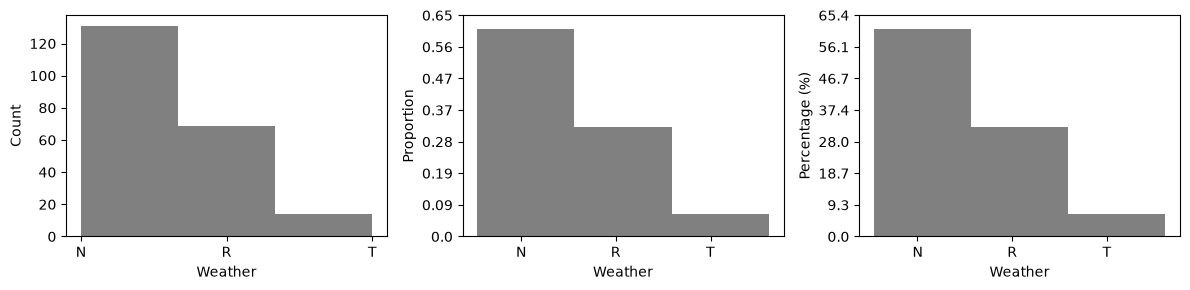

In [37]:
# Create histogram for a categorical column using hist()

fig, axs = plt.subplots(1,3, 
                        sharey=False, 
                        sharex=False, 
                        tight_layout=True, 
                        figsize=(12,3)) # define a figure with three subplots that are arranged as one row. yshare defines if the three plots share the y axis. xshare is similarly defined.

# frequency distribution
axs[0].hist(NY_bicycle.Weather, bins=3,color='grey')
axs[1].set_xticks(np.arange(0.3,2,0.65))
axs[0].set_xlabel('Weather')
axs[0].set_ylabel('Count')

# relative frequency distribution
axs[1].hist(NY_bicycle.Weather,bins=3, color='grey')
axs[1].set_xlabel('Weather')
axs[1].set_ylabel('Proportion')
axs[1].set_xticks(np.arange(0.3,2,0.65))
axs[1].set_yticks(axs[1].get_yticks())
axs[1].set_yticklabels((axs[1].get_yticks()/len(NY_bicycle)).round(2)) # ytick labels are in relative frequency and rounded to two decimal places

# percent frequency distribution
axs[2].hist(NY_bicycle.Weather,bins=3, color='grey')
axs[2].set_xlabel('Weather')
axs[2].set_ylabel('Percentage (%)')
axs[2].set_xticks(np.arange(0.3,2,0.65))
axs[2].set_yticks(axs[2].get_yticks())
axs[2].set_yticklabels((axs[2].get_yticks()/len(NY_bicycle)*100).round(1)) # ytick labels are in percent frequency and rounded to one decimal place

plt.show();

### Numerical Data

For numerical data, we often divide the range of values into equally spaced bins. The bins should be mutually exclusive and collectively exhaustive. Then we count how many observations fall into each bin.

Suggested exercises:

1. Build a basic understanding of the sample distribution of `Total`. Count the number of entries in `Total`, and find its minimum and maximum values.
2. Divide the range of `Total` into 9 bins, and count the observations in each bin. [Hint: use the `cut()` function and the `value_counts()` method]
3. [Optional] Plot a histogram of `Total` to show the distribution.

In [38]:
# The count() method returns the number of non-NA entries
NY_bicycle.Total.count() 

# max() returns the maximum value of a numerical column
NY_bicycle.Total.min() 

# min() returns the minimum value of a numerical column
NY_bicycle.Total.max() 

np.int64(214)

np.int64(2374)

np.int64(26969)

In [39]:
# The pandas.cut(data,bins=int) can split data into nonoverlapping segments

pd.cut(NY_bicycle.Total, bins=9).value_counts()

Total
(21503.444, 24236.222]    50
(16037.889, 18770.667]    42
(18770.667, 21503.444]    32
(24236.222, 26969.0]      31
(13305.111, 16037.889]    22
(10572.333, 13305.111]    14
(7839.556, 10572.333]     11
(5106.778, 7839.556]       8
(2349.405, 5106.778]       4
Name: count, dtype: int64

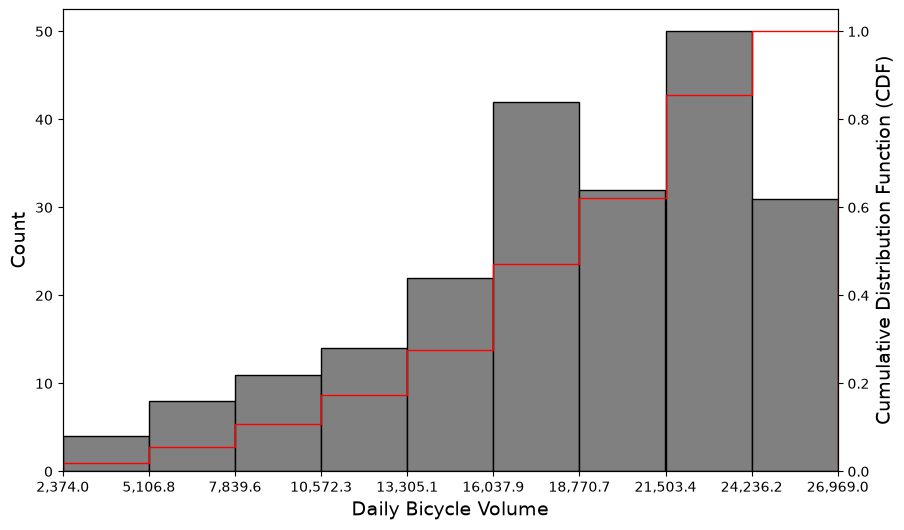

edges of the bins: [ 2374.      5106.7778  7839.5556 10572.3333 13305.1111 16037.8889
 18770.6667 21503.4444 24236.2222 26969.    ]
counts within each bin: [ 4.  8. 11. 14. 22. 42. 32. 50. 31.]


In [40]:
# generates a histogram for a numerical column using plt.hist()

fig, ax = plt.subplots(figsize=(10,6)) # define a figure of one plot of size 10x6 inch
ax2 = ax.twinx() # create the second y-axis to show the cumulative distribution

N_bins = 9 # number of bins

# create the frequency distribution
counts, bins, patches = ax.hist(NY_bicycle.Total, 
                                facecolor='grey',
                                edgecolor='black',
                                density=False, # density=False counts observations; density=True would show a probability density
                                bins=N_bins) 

# create the cumulative distribution
n, bins, patches = ax2.hist(NY_bicycle.Total, 
                            cumulative=True, 
                            density=True, 
                            histtype='step', 
                            color='red', 
                            bins=N_bins) 

ax.set_xlim([NY_bicycle.Total.min(),NY_bicycle.Total.max()])
ax.set_xticks(ticks=bins,
              rotation=0,
              labels=[f'{x:,.1f}' for x in bins]
          ) # x ticks are set to the boundaries of bins
ax.set_xlabel('Daily Bicycle Volume',fontsize=14)
ax.set_ylabel('Count',fontsize=14)
ax2.set_ylabel('Cumulative Distribution Function (CDF)',fontsize=14)

plt.show()

print('edges of the bins:', bins)
print('counts within each bin:', counts);


## Numerical Data Description

For numerical data, descriptive statistics summarize the center, spread, and shape of the data. They can also describe relationships between variables.

### Measures of Location

Mean, median, and mode are common statistics that describe the location, or center, of a data distribution.

The *mean* of a numerical variable $X$ is its expected value, $\text{E}[X]$, denoted by $\mu$:
\begin{equation}
\mu = \text{E}[X].
\end{equation}

Given a sample of the variable, the sample mean is
\begin{equation}
\overline{x} = \frac{\sum_{n=1}^N x_n}{N}
\end{equation}
where:
- $\overline{x}$ is the sample mean
- $N$ is the sample size
- $x_n$ is the $n$th observation of the variable $X$

The sample mean, $\bar{x}$, is an unbiased estimate of the population mean, $\mu$.

The *median* is the middle value when the data are arranged in ascending order. It is:
- the middle value when there is an odd number of observations
- the average of the two middle values when there is an even number of observations

The *mode* is the value, or values, that occur most frequently.
- Bimodal data have exactly two modes.
- Multimodal data have two or more modes.

Suggested exercises:

1. What is the mean value of `Total`?
2. What is the median value of `Total`?
3. What is the mode of `Total`?

In [41]:
# mean() returns the mean value
NY_bicycle.Total.mean()

# median() returns the median value
NY_bicycle.Total.median()

# mode() returns the mode(s)
NY_bicycle.Total.mode()

# From the calculation, can you tell the relationship of the total of daily bicycle counts mean, median, and mode?

np.float64(18627.67757009346)

np.float64(19367.0)

0    23159
Name: Total, dtype: int64

### Measures of Variability

Range, variance, and standard deviation are common statistics that describe the variability, or spread, of data.

The *range* of a numerical variable $X$ is the difference between the largest and smallest values:
\begin{equation}
\max(X)-\min(X).
\end{equation}

Because the range uses only two observations, it is highly influenced by extreme values.

*Variance*, denoted by $\sigma^2$, is the expected squared deviation from the mean:
\begin{equation}
\sigma^2=\text{Var}[X]=\text{E}[(X-\mu)^2]  =\text{E}[X^2]-\mu^2,
\end{equation}
which uses all observations to measure variability.

Given a sample of the variable, the *sample variance* is calculated as
\begin{equation}
s^2=\frac{\sum_{n=1}^N (x_n-\overline{x})^2}{N-1}.
\end{equation}

*Standard deviation*, denoted by $\sigma$, is the positive square root of the variance. Given a sample of the variable, the *sample standard deviation* is calculated as
\begin{equation}
s=\sqrt{\frac{\sum_{n=1}^N (x_n-\overline{x})^2}{N-1}}.
\end{equation}

The *coefficient of variation* (CV) describes how large the standard deviation is relative to the mean:
\begin{equation}
\text{CV}=\frac{\sigma}{\mu}.
\end{equation}

Suggested exercises:

1. Calculate the range of `Total`.
2. Calculate the variance of `Total`.
3. Calculate the standard deviation of `Total`.

In [42]:
# find the range of a numerical column
NY_bicycle.Total.max() - NY_bicycle.Total.min() 

# var() returns the variance
NY_bicycle.Total.var()

# std() returns the sample standard deviation
NY_bicycle.Total.std()

# coefficient of variation
NY_bicycle.Total.std()/NY_bicycle.Total.mean()

np.int64(24595)

np.float64(30686697.177241012)

np.float64(5539.557489298311)

np.float64(0.297383153023435)

### Measures of Shape

Skewness is the third moment of the standardized variable:
\begin{equation}
\text{Skewness}(X) = \text{E}\left[\left(\frac{X-\mu}{\sigma}\right)^3\right],
\end{equation}
and measures the asymmetry of the distribution.
- A negative skewness value indicates that the distribution is skewed to the left.
- A positive skewness value indicates that the distribution is skewed to the right.
- A skewness value of zero indicates that the distribution is symmetric.

Kurtosis is the fourth moment of the standardized variable:
\begin{equation}
\text{Kurtosis}(X) = \text{E}\left[\left(\frac{X-\mu}{\sigma}\right)^4\right],
\end{equation}
and describes tail behavior and peak shape.

Many software tools subtract 3.0 from the calculated kurtosis so that a normal distribution has a value of 0.0. This is called excess kurtosis.

- Positive excess kurtosis indicates heavier tails and a higher peak.
- Negative excess kurtosis indicates lighter tails and a lower peak.
- Zero excess kurtosis suggests tail behavior and peak shape similar to a normal distribution.

Suggested exercises:

1. What is the skewness of `Total`? How do you interpret the result?
2. What is the kurtosis of `Total`? How do you interpret the result?

In [43]:
# Skewness is a measure of the asymmetry of the distribution of a real-valued numerical variable
# skew() returns sample skewness

NY_bicycle.Total.skew().round(2)
# The skewness value is -0.78, indicating that the distribution is skewed to the left (i.e., with a long tail on the left side)

np.float64(-0.78)

In [44]:
# Kurtosis measures how heavy the tails of the distribution of a real-valued variable.
# kurtosis() returns the sample kurtosis
# Default value of the argument Fisher=True, then 3.0 is subtracted from the result to give 0.0 for a normal distribution.

NY_bicycle.Total.kurtosis().round(3)
# The kurtosis value is 0.005, suggesting that the tail and peak behaviors are close to a normal distribution

np.float64(0.005)

### Measures of Distribution

Quantiles and quartiles describe the distribution of data.

A *quantile* defines the value below which a specified fraction of observations falls.

The $p$-quantile tells us the point in the data where:
- approximately $p$ of the observations have values less than the $p$-quantile value
- approximately $(1-p)$ of the observations have values greater than the $p$-quantile value

Special quantiles include quartiles and percentiles:
- The 0.25-quantile is the 1st quartile and the 25th percentile.
- The 0.50-quantile is the 2nd quartile, the 50th percentile, and the median.
- The 0.75-quantile is the 3rd quartile and the 75th percentile.

Given a sample of size $N$, if we sort the sample data in ascending order, the approximate location of the $p$-quantile is
\begin{equation}
L_{p}=p(N+1)
\end{equation}

Suggested exercises:

1. What are the 1st, 2nd, and 3rd quartiles? [Hint: use `.quantile()`]
2. What is the 0.99 quantile? [Hint: use `.quantile()`]

In [45]:
# quantile() returns value(s) at the given quantile(s)

NY_bicycle.Total.quantile([0.25,0.5,0.75]) 

0.25    15704.75
0.50    19367.00
0.75    23151.50
Name: Total, dtype: float64

In [46]:
# 0.99 quantile
NY_bicycle.Total.quantile(0.99) 
# This indicates 99% of the recorded days had total bicycle counts less than or equal to about 26,700

np.float64(26700.3)

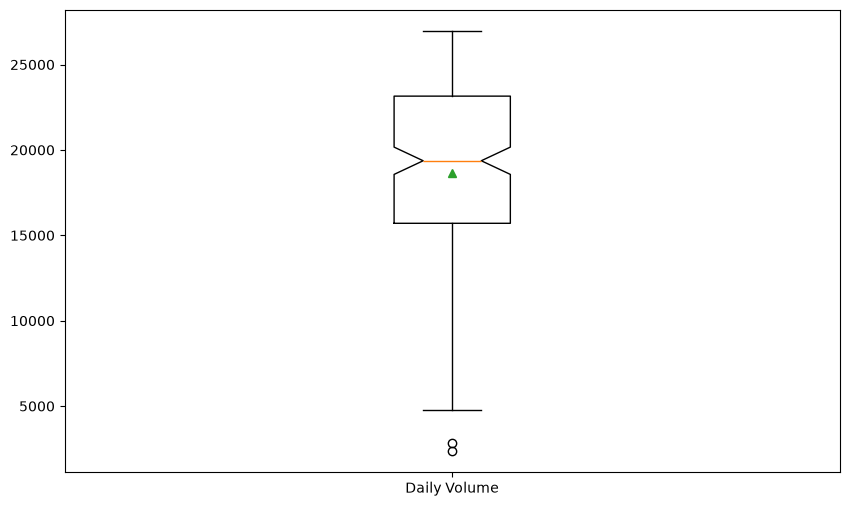

In [47]:
# Boxplot is often used to visualize data distribution. We can generate a boxplot using plt.boxplot() for a numerical variable

plt.subplots(figsize=(10,6))
plt.boxplot(NY_bicycle.Total,
            notch=True,
            tick_labels=['Daily Volume'],
            showfliers=True, 
            showcaps=True,
            showmeans=True)
plt.show();

# The boxplot indicates the distribution of daily total bicycle volume skews to the left (with a longer tail to the left). 
# There are two days with extremely low values (i.e., outliers)

A box plot summarizes a numerical distribution using:
- the 1st and 3rd quartiles, which define the edges of the box
- the median, which is the line inside the box
- the interquartile range (IQR), which is the distance between the 3rd and 1st quartiles
- the minimum value excluding outliers, often defined as values no smaller than Q1 - 1.5 IQR
- the maximum value excluding outliers, often defined as values no larger than Q3 + 1.5 IQR
- whiskers, which are the lines extending beyond the box
- outliers, which are data points outside the minimum and maximum values defined above

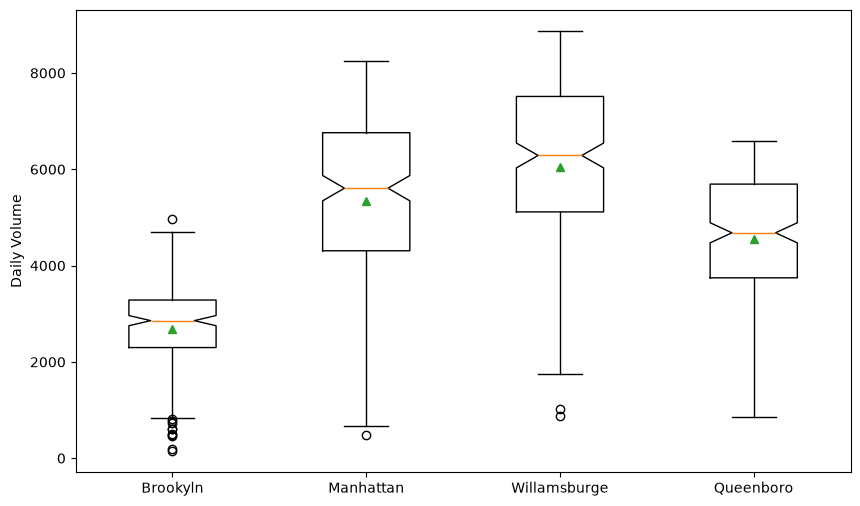

In [48]:
# generate a boxplot for each of multiple numerical variables

data = NY_bicycle.loc[:,["Brooklyn_Bridge", "Manhattan_Bridge","Williamsburg_Bridge", "Queensboro_Bridge"]]
labels = ['Brookyln','Manhattan','Willamsburge','Queenboro']

plt.subplots(figsize=(10,6))
plt.boxplot(data,
            notch=True,
            tick_labels=labels,
            showfliers=True, 
            showcaps=True,
            showmeans=True)
plt.ylabel('Daily Volume')
plt.show();

# What differences do you see about the distributions of the daily bicycle counts at respective bridges?


### Measures of Correlation

The *correlation coefficient* and *covariance* describe relationships between pairs of numerical variables.

The correlation coefficient measures the linear relationship between two variables, $X$ and $Y$:
\begin{equation}
r_{X,Y}=\frac{\text{E}[(X-\mu_X)(Y-\mu_Y)]}{\sigma_X\sigma_Y}=\frac{\text{E}[XY]-\mu_X\mu_Y}{\sigma_X\sigma_Y}
\end{equation}
where:
- $\mu_X$ is the mean of $X$
- $\sigma_X$ is the standard deviation of $X$
- $\mu_Y$ is the mean of $Y$
- $\sigma_Y$ is the standard deviation of $Y$

Given sample data for $X$ and $Y$, the sample correlation coefficient is
\begin{equation}
\hat{r}_{X,Y}=\frac{\frac{1}{N}\sum_{n=1}^N x_ny_n-\overline{x}_X\overline{x}_Y}{s_Xs_Y}
\end{equation}

The correlation coefficient ranges from -1 to 1. If two variables are independent, their correlation coefficient is zero. The reverse is not always true: two variables can have zero correlation and still be dependent. Can you think of an example?

Suggested exercises:

1. What is the correlation coefficient between each pair of numerical Series? [Hint: use `.corr(numerical_only=True)`]
2. What is the correlation between `Brooklyn_Bridge` and `Manhattan_Bridge`?
3. What is the covariance between each pair of numerical Series? [Hint: use `.cov(numerical_only=True)`]
4. What is the covariance between `Brooklyn_Bridge` and `Manhattan_Bridge`?

In [49]:
# corr() returns the correlation coefficient between any two numerical columns

NY_bicycle.corr(numeric_only=True).round(2)

# We can use the correlation matrix to study relationships among variables:
# For example, the correlation matrix shows negative correlations between precipitation and
# daily bicycle counts at the respective bridges, indicating that fewer people ride bicycles
# when it is raining


,High_Temp_F,Low_Temp_F,Precipitation,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
High_Temp_F,1.00,0.89,-0.19,0.49,0.46,0.48,0.50,0.49
Low_Temp_F,0.89,1.00,-0.05,0.29,0.29,0.31,0.35,0.32
Precipitation,-0.19,-0.05,1.00,-0.59,-0.55,-0.56,-0.54,-0.57
Brooklyn_Bridge,0.49,0.29,-0.59,1.00,0.89,0.89,0.88,0.92
Manhattan_Bridge,0.46,0.29,-0.55,0.89,1.00,0.98,0.96,0.99
Williamsburg_Bridge,0.48,0.31,-0.56,0.89,0.98,1.00,0.96,0.99
Queensboro_Bridge,0.50,0.35,-0.54,0.88,0.96,0.96,1.00,0.98
Total,0.49,0.32,-0.57,0.92,0.99,0.99,0.98,1.00


In [50]:
# corr() returns the correlation coefficient between two columns

NY_bicycle.Brooklyn_Bridge.corr(NY_bicycle.Manhattan_Bridge).round(2) 

np.float64(0.89)

In [51]:
# cov() returns the covariance between any two numerical columns

NY_bicycle.cov(numeric_only=True).round(2)

# covariance matrix is not normalized, and more difficult to interpret than correlation matrix

,High_Temp_F,Low_Temp_F,Precipitation,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
High_Temp_F,107.96,85.95,-0.79,4387.50,8405.58,8745.01,6811.74,28349.83
Low_Temp_F,85.95,86.60,-0.19,2340.21,4673.00,5136.58,4272.02,16421.81
Precipitation,-0.79,-0.19,0.17,-208.98,-397.27,-406.49,-289.49,-1302.23
Brooklyn_Bridge,4387.50,2340.21,-208.98,730530.66,1333902.83,1330993.57,978789.45,4374216.51
Manhattan_Bridge,8405.58,4673.00,-397.27,1333902.83,3050424.76,3012097.02,2190936.63,9587361.23
Williamsburg_Bridge,8745.01,5136.58,-406.49,1330993.57,3012097.02,3082886.28,2210714.77,9636691.64
Queensboro_Bridge,6811.74,4272.02,-289.49,978789.45,2190936.63,2210714.77,1707986.95,7088427.79
Total,28349.83,16421.81,-1302.23,4374216.51,9587361.23,9636691.64,7088427.79,30686697.18


In [52]:
# returns the covariance between two specific numerical columns

NY_bicycle.Brooklyn_Bridge.cov(NY_bicycle.Manhattan_Bridge).round(2) 

np.float64(1333902.83)

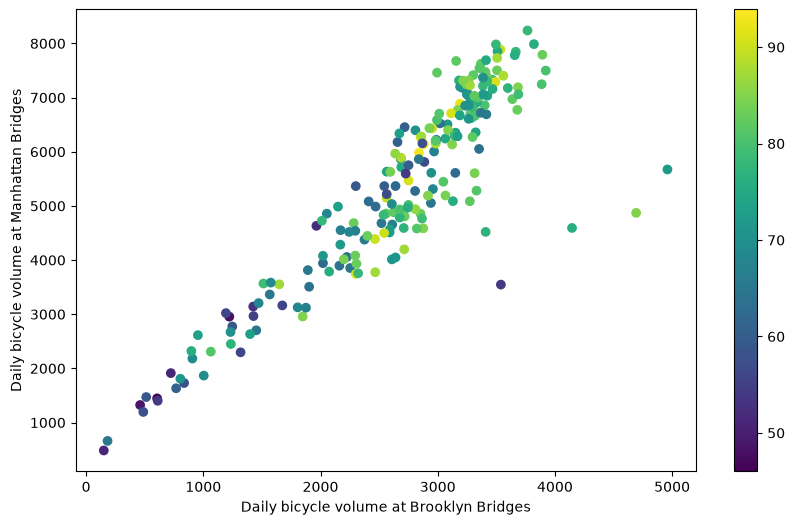

In [53]:
# generate scatter plot using plt.scatter() to visualize the correlation between two numerical variables

plt.subplots(figsize=(10,6))

plt.scatter(x=NY_bicycle.Brooklyn_Bridge,
            y=NY_bicycle.Manhattan_Bridge,
            c=NY_bicycle.High_Temp_F,
            cmap='viridis'
           ) # plt.scatter() returns a scatter plot of two numerical columns to show their association. The color is the 'High_Temp_F' value of each data point

plt.xlabel('Daily bicycle volume at Brooklyn Bridges') # plt.xlabel() defines the x label of the plot
plt.ylabel('Daily bicycle volume at Manhattan Bridges') # plt.ylabel() defines the y label of the plot

plt.colorbar() # displays the colorbar

plt.show();

# This figure shows that daily bicycle volumes at these bridges are positively correlated. 
# In general, days with higher temperatures are likely to have more people who ride bicycles.

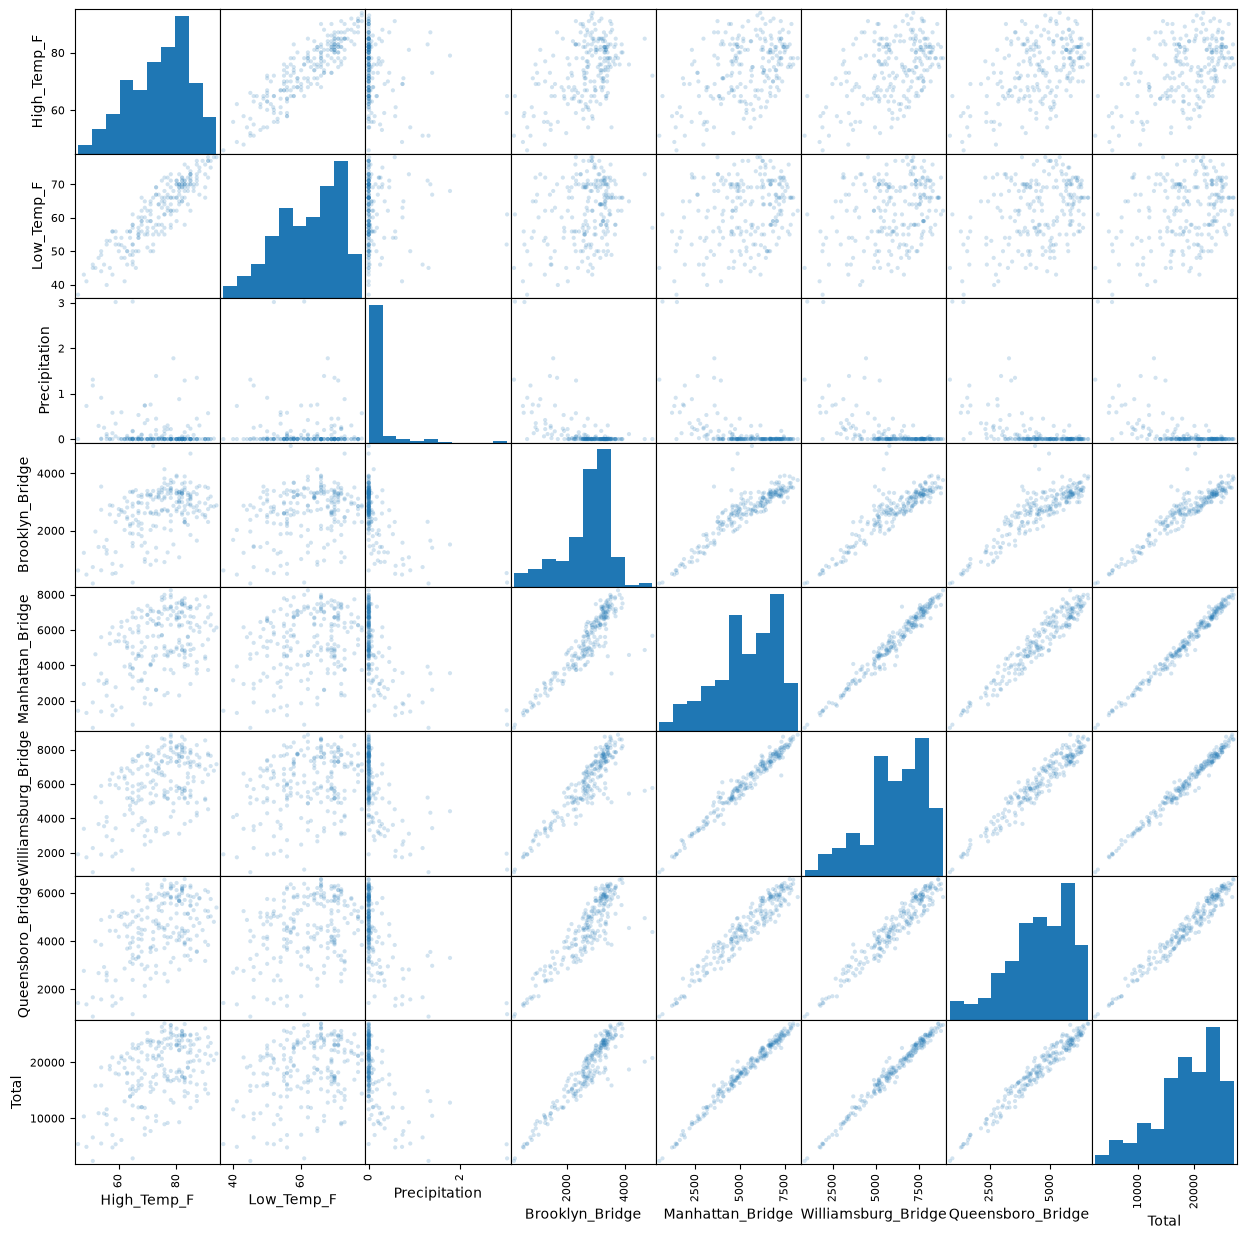

In [54]:
# generate scatter plot matrix using pd.plotting.scatter_matrix()

pd.plotting.scatter_matrix(NY_bicycle,
                           alpha=0.2,
                           figsize=(15,15)
                          ) # pd.plotting.scatter_matrix() generates the matrix of scatter plots
plt.show();

## Grouping and Aggregating Data

### Time Series

If a dataset contains records collected over time, it is often helpful to represent the data as a time series. In `NY_Bicycle.csv`, the `Date` column is stored as a string Series, and the `Day` column is also stored as a string Series. We can convert `Date` to a DateTime Series and convert `Day` to an ordered categorical variable. Then we can use methods designed for time series data.

Suggested exercises:

1. Convert the `NY_Bicycle` DataFrame into a time series dataset by creating a new DataFrame named `NY_bicycle_ts`. Its index should be a `DateTimeIndex` object based on the `Date` column. [Hint: consider `pandas.to_datetime()` and `.set_index()`]
2. Convert the string Series `Day` in `NY_bicycle_ts` into an ordered categorical variable. [Hint: set the arguments in `pandas.Categorical()`]
3. Calculate the average daily number of bicycles by `Day`. Format the counts as comma-separated numbers with 1 digit after the decimal point, such as `2,421.1`. What does your result look like if you skip step 2?
4. Count bicycles by month. Format the counts as comma-separated integers. [Hint: downsample to monthly data using the `resample()` method]

In [55]:
# save the DataFrame as a new one whose column "Date" is converted into the DateTimeIndex
# datetime format can be found from the link below
#https://docs.python.org/3/library/time.html#module-time
# %d-day in two digits
# %b - abbreviated month name
# %Y - year in four digits

Date_datetime = pd.to_datetime(NY_bicycle.Date+'-2017', format='%d-%b-%Y') # pandas.to_datetime() converts the string Series "Date" to DateTime
NY_bicycle_ts=NY_bicycle.set_index(Date_datetime) # set "Date" formatted as DateTime as the index
del NY_bicycle_ts['Date'] # drop the original column "Date"
NY_bicycle_ts.head()

,Day,High_Temp_F,Low_Temp_F,Precipitation,Weather,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
Date,,,,,,,,,,
2017-04-01,Saturday,46.0,37.0,0.00,N,606,1446,1915,1430,5397
2017-04-02,Sunday,62.1,41.0,0.00,N,2021,3943,4207,2862,13033
2017-04-03,Monday,63.0,50.0,0.03,R,2470,4988,5178,3689,16325
2017-04-04,Tuesday,51.1,46.0,1.18,R,723,1913,2279,1666,6581
2017-04-05,Wednesday,63.0,46.0,0.00,N,2807,5276,5711,4197,17991


In [56]:
# convert the Series "Day" to ordered categorical variable. 
# After that, the ranking of dataset according to "Day" is no longer in an alphabetical order, 
# but follows the order defined for this categorical variable

ordered_categories = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
NY_bicycle_ts['Day'] = pd.Categorical(NY_bicycle_ts['Day'], categories=ordered_categories, ordered=True)

In [57]:
# calculate average daily total count by day of week

NY_bicycle_ts.groupby('Day', 
                      observed=False
                     ).Total.mean().map('{:,.0f}'.format).to_frame("Daily Average")

# groupby "Day"
# aggregate data with mean()
# format data as comma separated values with 0 digit after the decimal point using .map() method
# use to_frame() to present result as a DataFrame

# The result shows that Wednesdays have the highest daily average count, followed by Thursday. 
# Weekends (Saturdays and Sundays) usually have lower counts 

,Daily Average
Day,
Monday,"18,539"
Tuesday,"20,254"
Wednesday,"21,892"
Thursday,"21,285"
Friday,"18,573"
Saturday,"15,048"
Sunday,"14,993"


In [58]:
# aggregate total counts by months
# resample() is a very useful function for changing the frequency of data. Data in NY_bicycle were recorded daily.
# resample("ME") downsamples or aggregates daily data into monthly data
NY_bicycle_ts.Total.resample("ME",closed="right", label="right").mean().map('{:,.0f}'.format).to_frame("Monthly Average")

# September and August have higher daily averages than other months

,Monthly Average
Date,
2017-04-30,"15,029"
2017-05-31,"17,196"
2017-06-30,"19,894"
2017-07-31,"18,805"
2017-08-31,"20,367"
2017-09-30,"20,435"
2017-10-31,"18,652"


### Aggregate Data with `groupby`

The `groupby` method divides a dataset into groups based on one or more attributes. After grouping, we can aggregate the data within each group using descriptive statistics.

Suggested exercises:

1. Aggregate daily bicycle counts into total counts by `Weather`, and name the aggregated value `Total Count`. Format the counts as comma-separated integers. [Hint: use `.map('{:,}'.format)` and `.to_frame('name')`]
2. Repeat step 1, but sort the values in ascending order.
3. Group data by `Weather`, and output the key and size of each subgroup. [Hint: the key and data for each subgroup are part of the output object]
4. Aggregate daily bicycle counts into total counts by `Weather` and `Day`. Format the counts as comma-separated integers.
5. Unstack the result from step 4 by changing `Weather` from an index level to columns. [Hint: use `unstack(level=...)`. To use `unstack`, first convert `Weather` and `Day` to index levels]
6. Group data by `Weather` and `Day`. Then calculate the following descriptive statistics for `Total` in each subgroup: mean, standard deviation, minimum, maximum, and median. Keep 1 digit after the decimal point. [Hint: use `.agg({dict})`]
7. Reset the index for the output from step 6. What changes do you observe?
8. [Optional] Group data by `Day`, then aggregate `Weather` values in each subgroup as a string. For example, if a subgroup has five data points with `Weather` values `N`, `N`, `R`, `N`, and `T`, the string is `N,N,R,N,T`. [Hint: consider the `join()` method]
9. [Optional] Group data by `Weather`, then aggregate `Day` values in each subgroup as a list.
10. Group data by `Day`, then determine the number of unique weather types that occurred on each day of the week. [Hint: use `.nunique()`]
11. Group data by `Weather`, then aggregate `Total` as the sum. Plot a bar chart to show the aggregated result. What do you observe? [Hint: use `.plot()`]
12. Group data by `Day`, then aggregate `Total` as the sum. Plot a line chart to show the aggregated result. What do you observe?
13. Group data by `Weather`. For each subgroup, aggregate `Total` as the mean and `Precipitation` as the standard deviation. [Hint: use `.agg({dict})`]
14. Group data by `Weather`, then get the subgroup where `Weather == 'T'`. [Hint: use `.get_group()`]
15. Group data by `Weather`, then generate a random sample of size 3 from each subgroup. [Hint: use `.apply(lambda x: x.sample(3))`]

In [59]:
# Let's find daily total bicycle counts by weather types

# groupby "Weather"
# aggregate data with mean()
# format data as comma separated values using .map
# use to_frame() to present result as a DataFrame and define column name

out4 = NY_bicycle_ts.groupby('Weather').Total.mean().map('{:,.0f}'.format).to_frame('Total Count') 
out4

,Total Count
Weather,
N,"20,926"
R,"14,170"
T,"19,088"


In [60]:
# After aggregating data, we often sort the aggregated data to facilitate data understanding
# find total bicycle counts by weather types, sorted in an ascending order

out5 = NY_bicycle_ts.groupby('Weather').Total.mean().sort_values().map('{:,.0f}'.format).to_frame('Total Count') 
out5

# Rainy days have fewer people riding bicycles

,Total Count
Weather,
R,"14,170"
T,"19,088"
N,"20,926"


In [61]:
# after grouped the data, key is an identifier for each group, and y is the data of each group

for key,y in NY_bicycle_ts.groupby('Weather'):
    print(f"the group for Weather {key} has {len(y)} data points")

the group for Weather N has 131 data points
the group for Weather R has 69 data points
the group for Weather T has 14 data points


In [62]:
# we can group data according to multiple attributes
# In this example, we group data first by "Weather" and then by "Day". The aggregated data is the sum of "Total" for each group.
out6 = NY_bicycle_ts.groupby(['Weather','Day'], 
                             observed=False
                            ).Total.mean().map('{:,.0f}'.format).to_frame("Total Count")
out6

# If observed=True, groups without observations will be skipped in the summary

Total Count
Weather Day                  
N       Monday         22,360
        Tuesday        23,116
        Wednesday      23,835
        Thursday       23,145
        Friday         21,373
        Saturday       16,142
        Sunday         16,599
R       Monday         12,118
        Tuesday        15,117
        Wednesday      18,889
        Thursday       15,359
        Friday         13,290
        Saturday       13,720
        Sunday         10,013
T       Monday         19,470
        Tuesday        22,754
        Wednesday      19,413
        Thursday       22,495
        Friday         17,622
        Saturday          nan
        Sunday         15,369

In [63]:
# Unstack the DataFrame

# reset_index().set_index(['Weather', 'Day']) will set these two columns as multi-indices.
# Then, we can use the unstack function. Default level to unstack is the lowest level, 
# which is "Day" in this example. We would like to unstack by "Weather", therefore, set level =0

out6.reset_index()

out6.reset_index().set_index(['Weather', 'Day'])

out6.reset_index().set_index(['Weather', 'Day']).unstack(level=0)

,Weather,Day,Total Count
0,N,Monday,"22,360"
1,N,Tuesday,"23,116"
2,N,Wednesday,"23,835"
3,N,Thursday,"23,145"
4,N,Friday,"21,373"
5,N,Saturday,"16,142"
6,N,Sunday,"16,599"
7,R,Monday,"12,118"
8,R,Tuesday,"15,117"
9,R,Wednesday,"18,889"


Total Count
Weather Day                  
N       Monday         22,360
        Tuesday        23,116
        Wednesday      23,835
        Thursday       23,145
        Friday         21,373
        Saturday       16,142
        Sunday         16,599
R       Monday         12,118
        Tuesday        15,117
        Wednesday      18,889
        Thursday       15,359
        Friday         13,290
        Saturday       13,720
        Sunday         10,013
T       Monday         19,470
        Tuesday        22,754
        Wednesday      19,413
        Thursday       22,495
        Friday         17,622
        Saturday          nan
        Sunday         15,369

Total Count                
Weather             N       R       T
Day                                  
Monday         22,360  12,118  19,470
Tuesday        23,116  15,117  22,754
Wednesday      23,835  18,889  19,413
Thursday       23,145  15,359  22,495
Friday         21,373  13,290  17,622
Saturday       16,142  13,720     nan
Sunday         16,599  10,013  15,369

In [64]:
# group data by "Weather" and "Day". For each subgroup, calculate descriptive statistics of "Total": mean, std, max, min, median

out7 = NY_bicycle_ts.groupby(['Weather','Day'],
                             observed=False
                            ).agg({'Total':['mean','std','max','min','median']}).map('{:,.1f}'.format)

out7

Total                                       
                       mean      std       max       min    median
Weather Day                                                       
N       Monday     22,359.6  2,321.5  25,680.0  16,860.0  23,045.0
        Tuesday    23,115.6  3,094.6  26,622.0  13,925.0  23,986.5
        Wednesday  23,835.2  2,343.3  26,969.0  17,991.0  23,223.5
        Thursday   23,145.4  2,409.3  26,360.0  18,290.0  23,923.0
        Friday     21,373.1  1,924.2  23,944.0  17,168.0  21,969.0
        Saturday   16,141.6  3,498.5  20,134.0   5,397.0  17,259.0
        Sunday     16,598.7  1,819.5  20,787.0  13,033.0  16,765.0
R       Monday     12,118.2  4,460.6  19,939.0   6,126.0  11,862.0
        Tuesday    15,116.6  6,678.1  24,946.0   5,493.0  16,638.0
        Wednesday  18,888.9  5,045.2  24,763.0   9,819.0  20,093.5
        Thursday   15,358.6  8,130.3  23,948.0   4,789.0  18,140.0
        Friday     13,289.7  5,552.4  23,539.0   5,356.0  12,805.0
        Saturday   13,719.6  4,415.9  19,043.0   2,374.0  14,781.0
        Sunday     10,012.6  4,281.9  15,878.0   2,835.0   9,865.0
T       Monday     19,470.5  2,284.7  21,086.0  17,855.0  19,470.5
        Tuesday    22,754.0  1,664.5  23,931.0  21,577.0  22,754.0
        Wednesday  19,413.0  5,071.4  22,999.0  15,827.0  19,413.0
        Thursday   22,495.0    896.6  23,129.0  21,861.0  22,495.0
        Friday     17,621.7  6,371.7  22,180.0  10,341.0  20,344.0
        Saturday        nan      nan       nan       nan       nan
        Sunday     15,369.3    961.6  16,408.0  14,510.0  15,190.0

In [65]:
# reset index

out7.reset_index()

Weather        Day     Total                                       
                           mean      std       max       min    median
0        N     Monday  22,359.6  2,321.5  25,680.0  16,860.0  23,045.0
1        N    Tuesday  23,115.6  3,094.6  26,622.0  13,925.0  23,986.5
2        N  Wednesday  23,835.2  2,343.3  26,969.0  17,991.0  23,223.5
3        N   Thursday  23,145.4  2,409.3  26,360.0  18,290.0  23,923.0
4        N     Friday  21,373.1  1,924.2  23,944.0  17,168.0  21,969.0
5        N   Saturday  16,141.6  3,498.5  20,134.0   5,397.0  17,259.0
6        N     Sunday  16,598.7  1,819.5  20,787.0  13,033.0  16,765.0
7        R     Monday  12,118.2  4,460.6  19,939.0   6,126.0  11,862.0
8        R    Tuesday  15,116.6  6,678.1  24,946.0   5,493.0  16,638.0
9        R  Wednesday  18,888.9  5,045.2  24,763.0   9,819.0  20,093.5
10       R   Thursday  15,358.6  8,130.3  23,948.0   4,789.0  18,140.0
11       R     Friday  13,289.7  5,552.4  23,539.0   5,356.0  12,805.0
12       R   Saturday  13,719.6  4,415.9  19,043.0   2,374.0  14,781.0
13       R     Sunday  10,012.6  4,281.9  15,878.0   2,835.0   9,865.0
14       T     Monday  19,470.5  2,284.7  21,086.0  17,855.0  19,470.5
15       T    Tuesday  22,754.0  1,664.5  23,931.0  21,577.0  22,754.0
16       T  Wednesday  19,413.0  5,071.4  22,999.0  15,827.0  19,413.0
17       T   Thursday  22,495.0    896.6  23,129.0  21,861.0  22,495.0
18       T     Friday  17,621.7  6,371.7  22,180.0  10,341.0  20,344.0
19       T   Saturday       nan      nan       nan       nan       nan
20       T     Sunday  15,369.3    961.6  16,408.0  14,510.0  15,190.0

In [66]:
# group data by "Day" and then convert values of "Weather" of each subgroup into a string

NY_bicycle_ts.groupby('Day', observed=False).Weather.apply(lambda Weather: ','.join(Weather)).to_frame('Instances')

,Instances
Day,
Monday,"R,N,T,T,N,N,N,R,R,R,N,R,N,R,N,N,R,N,R,N,N,N,N,N,N,N,N,R,R,N,R"
Tuesday,"R,N,N,R,N,N,N,N,R,R,T,R,R,N,N,N,N,N,N,R,R,R,T,N,R,N,N,N,N,R,N"
Wednesday,"N,R,T,R,N,N,N,R,R,N,R,N,N,N,N,N,N,R,N,N,T,R,R,R,N,N,N,R,N,N"
Thursday,"R,N,R,N,N,N,N,R,N,N,N,N,N,T,N,R,T,N,N,N,N,N,R,R,N,N,N,R,N,N"
Friday,"T,N,R,N,R,N,N,R,R,N,N,R,T,R,R,N,N,R,T,R,N,N,N,N,N,N,N,N,N,N"
Saturday,"N,N,N,R,R,R,R,R,N,R,N,R,R,R,N,N,R,N,R,R,N,N,R,N,N,N,N,N,R,N,N"
Sunday,"N,N,T,N,N,R,R,N,N,R,N,T,N,N,N,N,R,N,N,N,N,N,R,N,N,N,N,R,T,N,R"


In [67]:
# group data by "Weather" and then convert values of "Day" of each subgroup into a list 

# tolist() converts series into a list
NY_bicycle_ts.groupby('Weather').Day.apply(lambda Days: Days.tolist())

Weather
N    [Saturday, Sunday, Wednesday, Saturday, Sunday, Monday, Tuesday, Thursday, F...
R    [Monday, Tuesday, Thursday, Wednesday, Thursday, Friday, Saturday, Tuesday, ...
T    [Friday, Sunday, Monday, Wednesday, Monday, Tuesday, Sunday, Friday, Thursda...
Name: Day, dtype: object

In [68]:
# Group data by "Day" and then determine the unique weathers occurred on each day of week

NY_bicycle_ts.groupby('Day', observed=False).Weather.nunique().to_frame('Count Weather Types') # use nunique() to find the number of unique values by groups

,Count Weather Types
Day,
Monday,3
Tuesday,3
Wednesday,3
Thursday,3
Friday,3
Saturday,2
Sunday,3


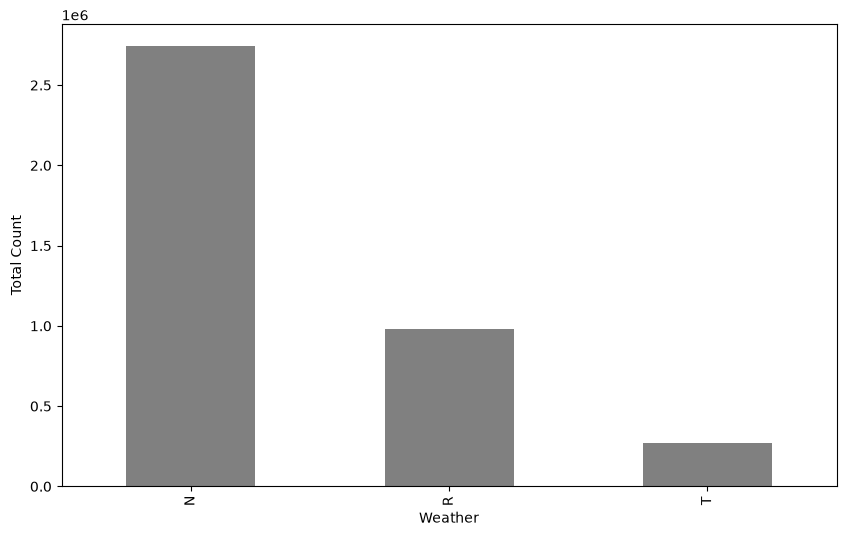

In [69]:
# a bar chart displaying the distribution of total count by "Weather"

plt.clf() # clear the current figure
NY_bicycle_ts.groupby('Weather').Total.sum().plot(kind='bar', color='grey') # sum() returns the total bicycle count in each group
plt.ylabel('Total Count');

# The figure shows that nearly 3 million bicycles were counted on no-rain days and nearly 1 million on rainy days.

                 mean          std
Weather                           
N        20926.213740  3876.824444
R        14170.304348  5816.202110
T        19088.428571  4077.086152


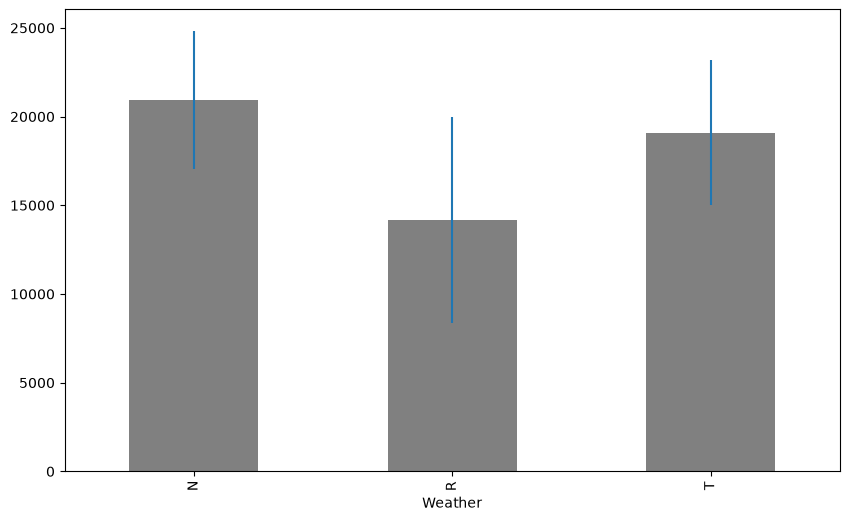

In [70]:
# a bar chart displaying the sample mean and sample standard deviation of 'Total' by weather groups

# create a bar chart of mean values of 'Total' by weather categories
plt.clf()
ax = plt.gca() # Get the current ~matplotlib.axes.Axes instance on the current figure matching the given keyword args, or create one.
NY_bicycle_ts.groupby('Weather').Total.mean().plot(kind='bar', color='grey', ax=ax)

# calculate the mean and the standard deviation of each group
out8 = NY_bicycle_ts.groupby('Weather').Total.agg(['mean','std']) # agg() aggregates using one or more operations over the specified axis
print(out8)

# add vertical lines to represent the variation of 'Total' of each group
for i, (index, row) in enumerate(out8.iterrows()): # iterrows() iterates over DataFrame rows as (row index, data series) pairs.
  Avg = row ['mean']
  Std = row ['std']
  ax.vlines(x=i, ymin=Avg-Std, ymax=Avg+Std) # ax.vlines(x, ymin, ymax) plots a vertical line at the location specified by x. The range of the line is from ymin to ymax
plt.show();

# Rainy days clearly have lower average daily counts

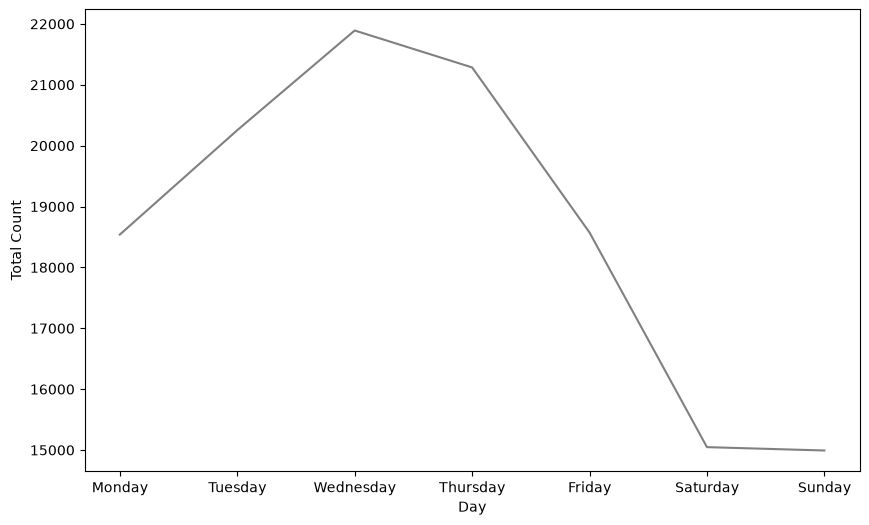

In [71]:
# a line chart displaying trend of total count by "Day"

plt.clf()
NY_bicycle_ts.groupby('Day', observed=False).Total.mean().plot(kind='line',color='grey')
plt.ylabel('Total Count');

In [72]:
# group data by "Weather". For each subgroup, calculate the standard deviation of "Total" and the mean of "Precipitation"

NY_bicycle_ts.groupby('Weather').agg({'Total':'std','Precipitation':'mean'}).map('{:,.1f}'.format) # group data by weather categories and calculate the standard deviation of 'Total' and the mean of 'Precipitation'

,Total,Precipitation
Weather,,
N,"3,876.8",0.0
R,"5,816.2",0.4
T,"4,077.1",nan


In [73]:
# group data by "Weather", and then get the slice with "Weather"=='T'

out9 = NY_bicycle_ts.groupby('Weather')
out9.get_group('T') # get_group() constructs DataFrame from group with provided name. 
# In this example, a DataFrame is constructed using group "T". Only 14 days were "T"

,Day,High_Temp_F,Low_Temp_F,Precipitation,Weather,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
Date,,,,,,,,,,
2017-04-07,Friday,48.0,43.0,NaN,T,1222,2955,3399,2765,10341
2017-04-16,Sunday,84.9,62.1,NaN,T,2877,4585,5259,3687,16408
2017-04-17,Monday,73.9,64.0,NaN,T,3152,6352,6924,4658,21086
2017-04-19,Wednesday,52.0,45.0,NaN,T,1965,4632,5234,3996,15827
2017-04-24,Monday,60.1,50.0,NaN,T,2544,5366,5762,4183,17855
2017-06-13,Tuesday,93.9,78.1,NaN,T,2882,6141,7155,5399,21577
2017-06-18,Sunday,84.0,72.0,NaN,T,2199,4014,4901,3396,14510
2017-06-30,Friday,88.0,73.9,NaN,T,2687,5890,7013,4754,20344
2017-07-06,Thursday,75.0,71.1,NaN,T,3065,6243,7302,5251,21861


In [74]:
# group data by "Weather" and then generate a random sample of size 3 from each of the subgroup
df_sample=NY_bicycle_ts.groupby('Weather').apply(lambda x: x.sample(3),include_groups=False).reset_index(drop=True) # sample() returns a random sample. reset_index(drop=True) means do not add the index as a column of the DataFrame
df_sample

,Day,High_Temp_F,Low_Temp_F,Precipitation,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
0,Saturday,75.9,68.0,0.00,2074,3787,5242,3711,14814
1,Monday,66.9,55.9,0.00,2685,5865,5981,4550,19081
2,Saturday,84.9,73.0,0.00,4693,4871,5612,4958,20134
3,Thursday,71.1,59.0,0.01,3249,7059,7717,5923,23948
4,Saturday,73.0,66.9,1.39,1399,2633,3439,2977,10448
5,Tuesday,82.0,72.0,0.03,3407,7473,7975,6091,24946
6,Tuesday,93.9,78.1,NaN,2882,6141,7155,5399,21577
7,Thursday,75.0,71.1,NaN,3065,6243,7302,5251,21861
8,Sunday,72.0,66.0,NaN,2169,4285,4943,3793,15190


### Cross-Tabulation

Cross-tabulation is a useful table format for describing the relationship between two variables.

#### Use `crosstab`

Suggested exercise:

1. Create a cross-tabulation to summarize the mean `Total` by `Weather` and `Day`. Show the margins. [Hint: use `Weather` as the index, `Day` as the columns, `Total` as the values, and mean as the aggregation method.]

In [75]:
# create a cross-tabulation to summarize data on two axes using pd.crosstab(index, column, values, aggfunc). index and column are the two axes, and values are aggregated using the specified aggfunc
# In this example, index is "Weather", column is "Day", values are "Total", and the aggfunc is mean. 

pd.crosstab(NY_bicycle_ts.Weather, # define row variable
            NY_bicycle_ts.Day, # define column variable
            margins=True, # margins=True will provide the margins of the crosstabulation
            values=NY_bicycle_ts.Total, # define values to be aggregated in this table
            aggfunc='mean' # aggregation method is mean
           ).map('{:,.0f}'.format) # define data format: comma separated with zero digits after the decimal point

Day,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday,All
Weather,,,,,,,,
N,"22,360","23,116","23,835","23,145","21,373","16,142","16,599","20,926"
R,"12,118","15,117","18,889","15,359","13,290","13,720","10,013","14,170"
T,"19,470","22,754","19,413","22,495","17,622",nan,"15,369","19,088"
All,"18,539","20,254","21,892","21,285","18,573","15,048","14,993","18,628"


#### Use `pivot_table`

`pivot_table` is another pandas function for generating cross-tabulations.

Suggested exercises:

1. Create a pivot table to summarize data along two axes using `pd.pivot_table(DataFrame, values, index, columns, aggfunc, margins)`. Use `Weather` as the index, `Day` as the columns, `Total` as the values, and mean as the aggregation method. Include margins in the table.
2. Create a pivot table to summarize the mean values of `Brooklyn_Bridge` and `Total` by `Weather` and `Day`. Use `Weather` as the index, `Day` as the columns, `Brooklyn_Bridge` and `Total` as the values, and `numpy.mean` as the aggregation function. [Hint: pass a dictionary to `aggfunc`; the dictionary specifies which function is used to aggregate each value]
3. Create a pivot table to summarize the mean and standard deviation of `Total` by `Weather` and `Day`. Use `Weather` as the index, `Day` as the columns, `Total` as the value, and `numpy.mean` and `numpy.std` as the aggregation functions. [Hint: pass a list of functions to `aggfunc`]
4. Create a table summarizing the mean values of `High_Temp_F` and `Low_Temp_F` when `Weather` is `T`. [Hint: create a pivot table with two indices, `Weather` and `Day`. Use `High_Temp_F` and `Low_Temp_F` as the values and mean as the aggregation function. Then get the slice where `Weather == 'T'` using `DataFrame.query()`]
5. Create a table summarizing the mean values of `High_Temp_F` and `Low_Temp_F` on Friday when `Weather` is `N` and `R`, respectively. [Hint: create a pivot table with two indices, `Weather` and `Day`. Use `High_Temp_F` and `Low_Temp_F` as the values and mean as the aggregation function. Then get the slice where `Weather` is `N` or `R` and `Day == 'Friday'`]

In [76]:
# summarize mean of "Total" by "Weather" and "Day"

pd.pivot_table(NY_bicycle_ts, # the dataset to be summarized 
               index=['Weather'], # define row variable
               columns=['Day'], # define column variable
               values=['Total'], # define the variable to be presented in the table
               aggfunc='mean', # method for aggregating data
               margins=True, # show margins
               observed=True  # do not display row or column combinations with no observations
              ).map('{:,.1f}'.format) # define data format: comma separated and one digit after the decimal point

Total                                                              \
Day        Monday   Tuesday Wednesday  Thursday    Friday  Saturday    Sunday   
Weather                                                                         
N        22,359.6  23,115.6  23,835.2  23,145.4  21,373.1  16,141.6  16,598.7   
R        12,118.2  15,116.6  18,888.9  15,358.6  13,289.7  13,719.6  10,012.6   
T        19,470.5  22,754.0  19,413.0  22,495.0  17,621.7       nan  15,369.3   
All      18,539.1  20,253.9  21,891.6  21,285.1  18,572.9  15,047.8  14,992.5   

                   
Day           All  
Weather            
N        20,926.2  
R        14,170.3  
T        19,088.4  
All      18,627.7

In [77]:
# create crosstabulation using pd.pivot_table create a pivot table 
# to summarize the mean values of "Brooklyn_Bridge" and "Total" by "Weather" and "Day"

pd.pivot_table(NY_bicycle_ts,
               index=['Day'],
               columns=['Weather'],
               values=['Brooklyn_Bridge','Total'], 
               aggfunc={'Brooklyn_Bridge':'mean','Total':'mean'},
               margins=False,
               observed=False
              ).map('{:,.0f}'.format)

Brooklyn_Bridge                 Total                
Weather                 N      R      T       N       R       T
Day                                                            
Monday              3,184  1,642  2,848  22,360  12,118  19,470
Tuesday             3,270  1,908  3,063  23,116  15,117  22,754
Wednesday           3,326  2,512  2,480  23,835  18,889  19,413
Thursday            3,236  2,004  3,176  23,145  15,359  22,495
Friday              3,035  1,774  2,352  21,373  13,290  17,622
Saturday            2,510  2,195    nan  16,142  13,720     nan
Sunday              2,779  1,648  2,415  16,599  10,013  15,369

In [78]:
# create crosstabulation using pd.pivot_table(data,index,columns,values, aggfunc)

pd.pivot_table(NY_bicycle_ts,
               index=['Day'],
               columns=['Weather'],
               values=['Total'], 
               aggfunc=['mean','std'],
               margins=False,
               observed=False
              ).map('{:,.0f}'.format)

mean                    std              
            Total                  Total              
Weather         N       R       T      N      R      T
Day                                                   
Monday     22,360  12,118  19,470  2,321  4,461  2,285
Tuesday    23,116  15,117  22,754  3,095  6,678  1,665
Wednesday  23,835  18,889  19,413  2,343  5,045  5,071
Thursday   23,145  15,359  22,495  2,409  8,130    897
Friday     21,373  13,290  17,622  1,924  5,552  6,372
Saturday   16,142  13,720     nan  3,498  4,416    nan
Sunday     16,599  10,013  15,369  1,819  4,282    962

In [79]:
# create a table summarizing the mean values of "High_Temp_F" and "Low_Temp_F" when Weather is 'T'
# using query() function to extract part of the summary table

out10 = pd.pivot_table(NY_bicycle_ts,
                       index=['Weather','Day'],
                       values=['High_Temp_F','Low_Temp_F'],
                       aggfunc=['mean'], 
                       margins=True,
                       observed=False
                      ).map('{:,.1f}'.format)


out10.query("Weather==['T']") 

mean           
                  High_Temp_F Low_Temp_F
Weather Day                             
T       Monday           67.0       57.0
        Tuesday          89.0       74.0
        Wednesday        66.0       58.0
        Thursday         76.0       69.0
        Friday           72.3       62.3
        Sunday           80.3       66.7

In [80]:
# create a table summarizing the mean values of "High_Temp_F" and "Low_Temp_F" for Friday 
# and when Weather is 'N' and 'R' respectively

out11 = pd.pivot_table(NY_bicycle,
                      index=['Weather','Day'],
                      values=['High_Temp_F','Low_Temp_F'],
                      aggfunc=['mean'], 
                      margins=True,
                      observed=False
                      ).map('{:,.1f}'.format)

out11.query("Weather==['N','R'] & Day =='Friday'")

mean           
               High_Temp_F Low_Temp_F
Weather Day                          
N       Friday        75.2       61.2
R       Friday        72.7       63.1